## Feature engineering

In this section we are going to focus on the features, we are going to apply featurer engineering to create new useful features from the ones we already have.

Time:
We are going to create a new column called Hour, we are goin to transform the Time column into something more meaninful like the hour of the day.

Amount:
We are going to transoform this column because here we have extreme outliers and the distribution is huge, so we are going to scale this feature using log scale to compress the data to ~10 units without losing information, avoid long conversion times and model incorrect bias and bette visual class separation.

In [19]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

df = pd.read_csv('../creditcard.csv')

# New features created based on EDA insights
# 1. Hour  — capture the hour of the day when the transaction occurred
# 2. Amount_log — scale the transaction amount using log transformation to reduce skewness

df['Hour'] = (df['Time'] / 3600) % 24
df['Amount_log'] = np.log1p(df['Amount'])

# Verifying the new columns created
print("New columns created:")
print(df[['Amount', 'Amount_log', 'Hour']].describe().round(3))

ModuleNotFoundError: No module named 'sklearn'

We can see that the trasformation was correct.

In the next section we are going to visually confirm the impact of the transforamtion in the data.

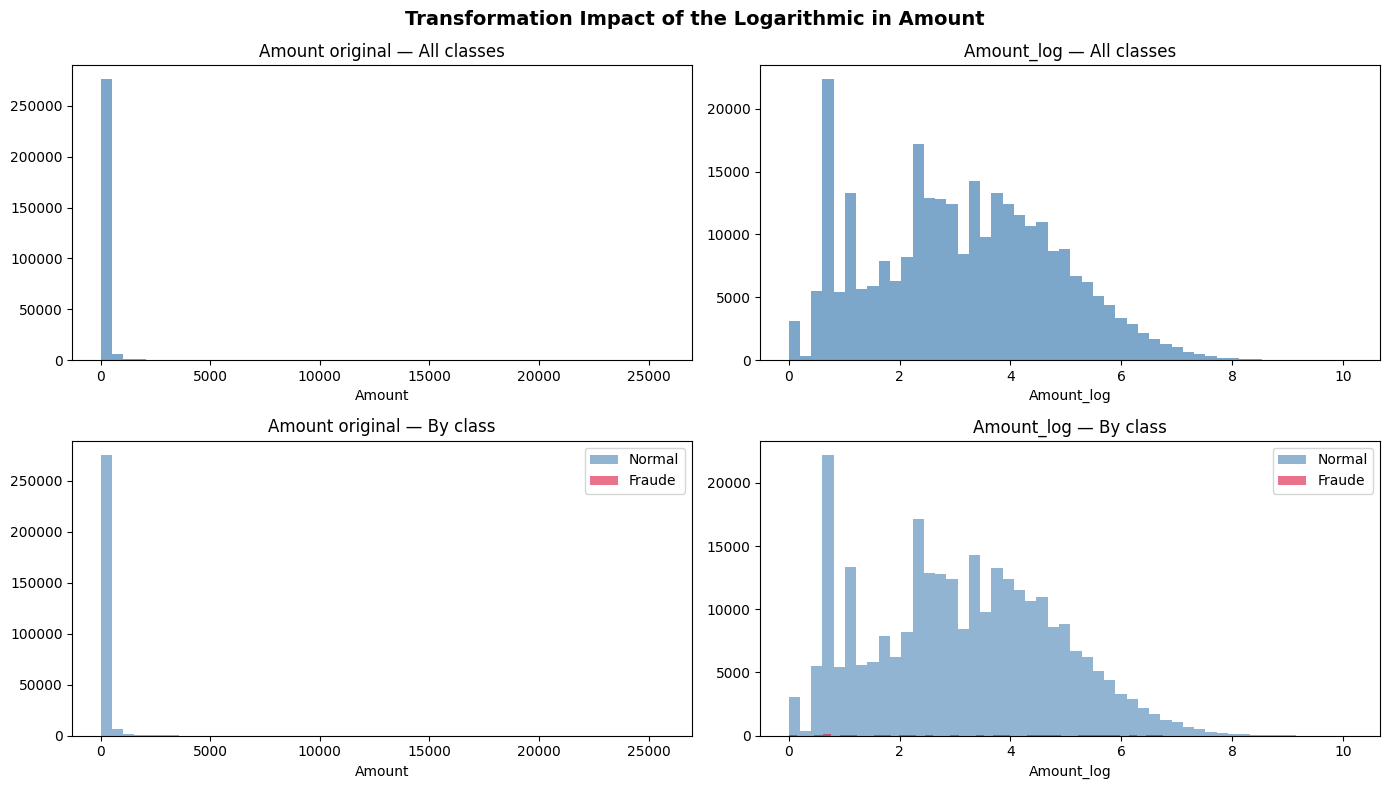

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original amount
axes[0,0].hist(df['Amount'], bins=50, color='steelblue', alpha=0.7)
axes[0,0].set_title('Amount original — All classes')
axes[0,0].set_xlabel('Amount')

axes[0,1].hist(df['Amount_log'], bins=50, color='steelblue', alpha=0.7)
axes[0,1].set_title('Amount_log — All classes')
axes[0,1].set_xlabel('Amount_log')

# By class
for clase, color, label in zip([0, 1],
                                ['steelblue', 'crimson'],
                                ['Normal', 'Fraude']):
    subset = df[df['Class'] == clase]
    axes[1,0].hist(subset['Amount'], bins=50,
                   alpha=0.6, color=color, label=label)
    axes[1,1].hist(subset['Amount_log'], bins=50,
                   alpha=0.6, color=color, label=label)

axes[1,0].set_title('Amount original — By class')
axes[1,0].set_xlabel('Amount')
axes[1,0].legend()

axes[1,1].set_title('Amount_log — By class')
axes[1,1].set_xlabel('Amount_log')
axes[1,1].legend()

plt.suptitle('Transformation Impact of the Logarithmic in Amount',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../amount_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

Here we can see the effect of Amount log scaling, data is more compressed withoud loosing information and visually is more clear.

In this section we are going to update the final dataset dropping the old Time and Amount columns.

In [7]:
# Dropping the original 'Time' and 'Amount' columns as they are no longer needed for modeling
df_model = df.drop(columns=['Time', 'Amount'])

# Verifying the final shape and columns of the dataset after feature engineering
print("Final shape:", df_model.shape)
print("\nFinal columns:", df_model.columns.tolist())

Final shape: (284807, 31)

Final columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour', 'Amount_log']


### Feature/Target

In this section we are going to split the dataframe in feature and target. 

In [8]:
# Splitting the dataset into features (X) and target variable (y)
X = df_model.drop(columns=['Class'])
y = df_model['Class']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nClass distribution in y:")
print(y.value_counts())

Shape of X: (284807, 30)
Shape of y: (284807,)

Class distribution in y:
Class
0    284315
1       492
Name: count, dtype: int64


### Train/Test split

In this section we are going to separate train and test data, we are going to use stratified data splitting to be sure are are having equal amount of the minority class in each set.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # maintains class proportion
)

# Verify distribution
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

print("\nDistribution in train:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nDistribution in test:")
print(y_test.value_counts(normalize=True).round(4) * 100)

ModuleNotFoundError: No module named 'sklearn'